# 05 — DOMINANT vs GAD-NR: Grafo de Miembros (M)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo de miembros `M`
usando la librería **PyGOD 1.1.0**:

- **DOMINANT** (Ding et al., SDM 2019): línea base consolidada en la literatura — encoder GCN
  compartido con dos decoders que reconstruyen estructura y atributos por separado.
- **GAD-NR** (Roy et al., WSDM 2024): estado del arte en la familia GNN+AE — reconstruye el
  vecindario completo de cada nodo (features propias, grado y distribución de atributos de vecinos).

## ¿Por qué este par de modelos?

Ambos pertenecen a la misma familia arquitectónica (GNN + Autoencoder, no supervisado) y
operan sobre el mismo objeto `Data` de PyG, lo que hace la comparativa limpia y directa.
La diferencia fundamental está en **qué reconstruyen**:

| Modelo | Reconstruye | Detecta bien |
|--------|------------|---------------|
| DOMINANT | Adyacencia $\hat{A}$ + features $\hat{X}$ | Anomalías estructurales y de atributos por separado |
| GAD-NR | Vecindario completo (features, grado, distribución de vecinos) | Anomalías contextuales, estructurales y joint-type |

## Esquema del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Imports y configuración |
| 1 | Carga del grafo M |
| 2 | Fundamento teórico: DOMINANT y GAD-NR |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Consenso final y tipología de anomalías |
| 6 | Spotlight — candidatos del EDA |
| 7 | Comparativa DOMINANT vs GAD-NR |
| 8 | Guardado de resultados |

## 0. Imports y configuración

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from pygod.detector import DOMINANT, GADNR
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo M

Cargamos el objeto `Data` del grafo M generado en el notebook `04_feature_engineering.ipynb`.
Tanto DOMINANT como GAD-NR usan el grafo completo durante el entrenamiento — no hacen split
de aristas porque son modelos de detección de anomalías no supervisados, no de predicción de
enlaces. Necesitan ver toda la estructura para aprender el patrón normal.

PyGOD requiere un objeto `Data` con solo `x` y `edge_index` — los atributos adicionales
como `member_ids` o `edge_weight` deben eliminarse para evitar errores de conversión.

In [2]:
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)
print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')

# Guardamos los IDs originales antes de limpiar el objeto Data
member_ids = data_M.member_ids  # lista de member_id en el mismo orden que los nodos

# Objeto limpio para PyGOD — solo x y edge_index
data_M_clean = Data(
    x=data_M.x,
    edge_index=data_M.edge_index,
)
print(f'\ndata_M_clean: {data_M_clean}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas únicas : 1176024
Features/nodo  : 3

data_M_clean: Data(x=[11371, 3], edge_index=[2, 2352048])


In [3]:
# Metadatos de miembros para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))

# DataFrame base indexado por member_id — se enriquecerá con los scores
id_to_idx = {mid: i for i, mid in enumerate(member_ids)}
base_df = pd.DataFrame({'member_id': member_ids})
base_df['idx'] = base_df.index
base_df = base_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    on='member_id', how='left'
)

# Grado de cada nodo (aristas únicas / 2 porque el grafo es no dirigido y duplicado)
edge_src = data_M.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_M.num_nodes) // 2  # cada arista aparece dos veces
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
base_df.head()

base_df: (11371, 6)


,member_id,idx,name,city,state,degree
0,2069,0,Wesley Duffee-Braun,Brentwood,TN,219
1,8386,1,Tim,Nashville,TN,307
2,9205,2,Brenda,Brentwood,TN,334
3,42506,3,Chris Meador,Nashville,TN,122
4,106758,4,Kt,Antioch,TN,119


## 2. Fundamento teórico: DOMINANT y GAD-NR

### 2.1 DOMINANT (Ding et al., SDM 2019)

DOMINANT extiende el GAE estándar con un segundo decoder. Tiene tres componentes:

**Encoder GCN compartido.** Produce embeddings latentes $Z$ combinando features $X$ y estructura $A$:
$$Z = \text{GCN}(X, A)$$

**Decoder de estructura.** Producto interno con sigmoide — idéntico al GAE clásico:
$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$

**Decoder de atributos.** Una GCN que reconstruye la matriz de features original desde los embeddings:
$$\hat{X} = \text{GCN}(Z, A)$$

La función de pérdida combina los dos errores de reconstrucción ponderados por `weight` $\in [0, 1]$:
$$\mathcal{L} = (1 - w) \cdot \|A - \hat{A}\|_F^2 + w \cdot \|X - \hat{X}\|_F^2$$

El anomaly score de cada nodo se calcula de forma análoga:
$$s_i = (1 - w) \cdot s_i^{struct} + w \cdot s_i^{attr}$$

En este notebook tratamos $s_i^{struct}$ y $s_i^{attr}$ como **señales independientes**
para mantener la distinción entre anomalía estructural y de atributo.

### 2.2 GAD-NR (Roy et al., WSDM 2024)

GAD-NR parte de la limitación clave de DOMINANT y los GAE clásicos: al reconstruir solo
los enlaces directos, los nodos conectados se agrupan en el espacio latente, lo que hace
que el modelo sea bueno detectando anomalías de tipo cluster pero no anomalías más complejas.

La solución es reconstruir el **vecindario completo** de cada nodo, capturando tres dimensiones:

**Reconstrucción de features propias.** Error entre las features reales del nodo y su reconstrucción:
$$\mathcal{L}_{feat} = \|x_i - \hat{x}_i\|^2$$

**Reconstrucción de grado.** Error entre el grado real y el grado predicho por un decoder MLP:
$$\mathcal{L}_{deg} = \text{CrossEntropy}(d_i, \hat{d}_i)$$

**Reconstrucción de la distribución de vecinos.** Divergencia KL entre la distribución real
de features de los vecinos y la distribución reconstruida (modelada como Gaussiana):
$$\mathcal{L}_{neigh} = D_{KL}(p_{neigh}(x) \| q_{neigh}(z))$$

La pérdida total combina las tres con pesos `lambda_loss1` (vecindario), `lambda_loss2` (features)
y `lambda_loss3` (grado). El anomaly score final es la combinación ponderada de las tres pérdidas
por nodo.

### 2.3 Hiperparámetros para el grafo M

| Hiperparámetro | DOMINANT | GAD-NR | Justificación |
|---|---|---|---|
| `hid_dim` | 64 | 64 | Dimensión latente estándar |
| `num_layers` | 4 | 1 | DOMINANT: 2 enc + 2 dec. GAD-NR: encoder ligero, decoders MLP |
| `dropout` | 0.0 | 0.0 | Grafo grande, sin riesgo significativo de sobreajuste |
| `weight` / — | 0.2 | — | DOMINANT: más peso a estructura (0.8) que a atributos (0.2), justificado porque M solo tiene 3 features geográficas frente a >1M aristas |
| `lambda_loss1/2/3` | — | 0.01/0.1/0.8 | GAD-NR: defaults del paper — más peso al grado que al vecindario |
| `epoch` | 200 | 200 | Convergencia suficiente para ambos modelos |
| `lr` | 0.004 | 0.01 | Defaults de PyGOD para cada modelo |
| `contamination` | 0.05 | 0.05 | P95 como umbral — 5% de anomalías esperadas |
| `batch_size` | 0 | 0 | Full batch — 11.371 nodos es manejable |
| `save_emb` | True | True | Guardar embeddings para análisis posterior |

## 3. Entrenamiento de DOMINANT

PyGOD usa una API similar a scikit-learn: se instancia el detector con los hiperparámetros
y se llama a `fit(data)`. Los scores quedan en `detector.decision_score_` y las etiquetas
binarias en `detector.label_` (determinadas por `contamination`).

Para acceder a los scores de estructura y atributo por separado realizamos un forward pass manual con el modelo interno `detector.model` tras el entrenamiento.

In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.2,         # peso del error de atributo: bajo porque M tiene solo 3 features
    contamination=0.05, # P95 — 5% de anomalías
    lr=0.004,
    epoch=200,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo M...')
dominant.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')

Entrenando DOMINANT sobre el grafo M...
Epoch 0000: Loss 10.4131 |  | Time 0.87
Epoch 0001: Loss 10.3505 |  | Time 0.25
Epoch 0002: Loss 10.3175 |  | Time 0.25
Epoch 0003: Loss 10.3266 |  | Time 0.25
Epoch 0004: Loss 10.3100 |  | Time 0.25
Epoch 0005: Loss 10.3069 |  | Time 0.26
Epoch 0006: Loss 10.2925 |  | Time 0.25
Epoch 0007: Loss 10.2915 |  | Time 0.26
Epoch 0008: Loss 10.2700 |  | Time 0.26
Epoch 0009: Loss 10.2588 |  | Time 0.25
Epoch 0010: Loss 10.2523 |  | Time 0.25
Epoch 0011: Loss 10.2477 |  | Time 0.25
Epoch 0012: Loss 10.2322 |  | Time 0.25
Epoch 0013: Loss 10.2183 |  | Time 0.25
Epoch 0014: Loss 10.2056 |  | Time 0.24
Epoch 0015: Loss 10.1993 |  | Time 0.26
Epoch 0016: Loss 10.1893 |  | Time 0.24
Epoch 0017: Loss 10.1825 |  | Time 0.25
Epoch 0018: Loss 10.1741 |  | Time 0.25
Epoch 0019: Loss 10.1654 |  | Time 0.24
Epoch 0020: Loss 10.1589 |  | Time 0.25
Epoch 0021: Loss 10.1489 |  | Time 0.25
Epoch 0022: Loss 10.1460 |  | Time 0.25
Epoch 0023: Loss 10.1414 |  | Time 0.26


In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo por separado desde DOMINANT.

    DOMINANTBase.forward() devuelve (x_hat, s_hat) donde:
      x_hat : features reconstruidas [N, in_dim]
      s_hat : adyacencia reconstruida densa [N, N]  (generada por process_graph)

    Returns
    -------
    struct_scores : np.ndarray [N]  — MSE por fila de A
    attr_scores   : np.ndarray [N]  — MSE por nodo en features
    """
    model = detector.model
    model.eval()

    # process_graph añade la adyacencia densa data.s al objeto Data
    data_proc = data.clone()
    model.process_graph(data_proc)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)  # adyacencia densa real [N, N]

    # Forward: devuelve (x_hat, s_hat)
    x_hat, s_hat = model(x, edge_index)

    # Error de atributo por nodo: MSE entre X real y X reconstruida
    attr_scores   = ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()

    # Error de estructura por nodo: MSE entre fila real y fila reconstruida de A
    struct_scores = ((s_real - s_hat) ** 2).mean(dim=1).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.6f}, max={dom_struct.max():.6f}, mean={dom_struct.mean():.6f}')
print(f'DOM attr   — min={dom_attr.min():.6f},  max={dom_attr.max():.6f},  mean={dom_attr.mean():.6f}')

# Verificación: el score combinado debe coincidir con (1-weight)*struct + weight*attr
score_check = (1 - dominant.weight) * dom_struct + dominant.weight * dom_attr
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación fórmula combinada — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=0.000240, max=0.135284, mean=0.015481
DOM attr   — min=0.000000,  max=607.021667,  mean=0.905714

Verificación fórmula combinada — correlación con decision_score_: 0.039189
(debería ser ~1.0)


In [6]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo de DOMINANT.
    
    double_recon_loss calcula:
      attr_error   = sqrt(sum((x - x_)^2, dim=1))
      struct_error = sqrt(sum((s - s_)^2, dim=1))
      score = weight * attr_error + (1 - weight) * struct_error
    """
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)  # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    # RMSE por nodo — igual que double_recon_loss
    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

# Verificación: score = weight*attr + (1-weight)*struct
score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=1.6522, max=39.2214, mean=12.1123
DOM attr   — min=0.0010,  max=42.6739,  mean=0.7548

Verificación — correlación con decision_score_: 0.999783
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_score_distributions_M.png


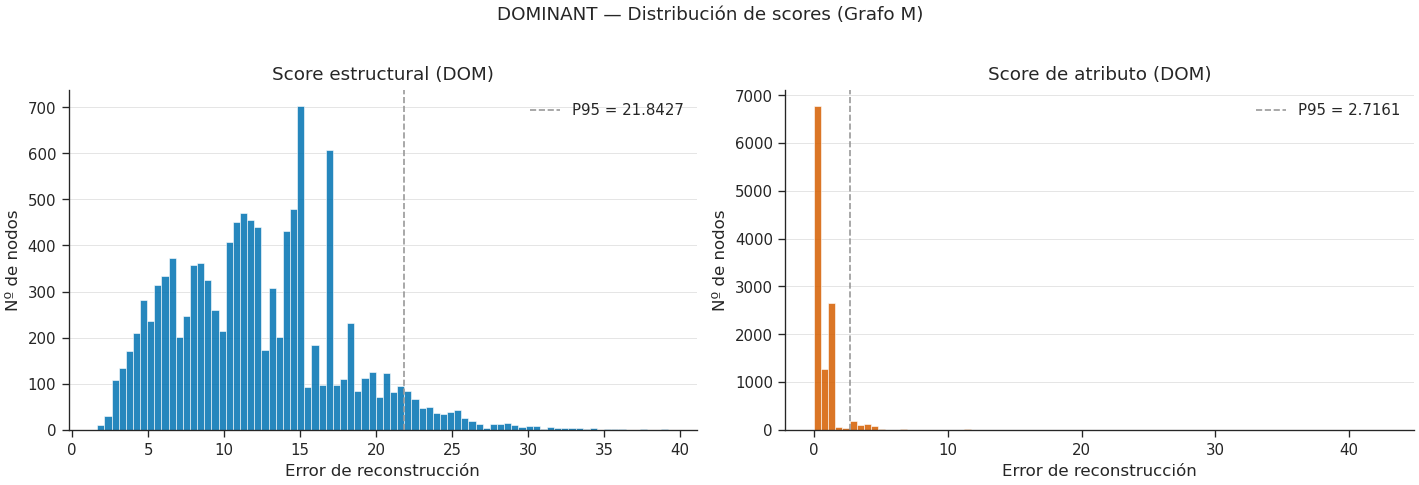

Correlación Spearman struct vs attr (DOMINANT): ρ = -0.0961


In [7]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['M'], PALETTE['anomaly']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['neutral'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo M)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_dominant_score_distributions_M.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')

## 4. Entrenamiento de GAD-NR

GAD-NR tiene una arquitectura más compleja que DOMINANT. El encoder combina un MLP de
reducción de dimensionalidad seguido de un GNN de paso de mensajes. El decoder tiene tres
cabezas independientes: un MLP para las features propias, un MLP para el grado, y una
distribución Gaussiana para los atributos de los vecinos.

**Nota sobre `num_layers=1`:** en GAD-NR este parámetro controla el número de capas del
*encoder GNN*, no del modelo completo. El paper original usa 1 capa de encoder — añadir
más capas aumenta el over-smoothing y degrada la detección.

**Nota sobre `real_loss=False` y los lambdas en este grafo.** GAD-NR implementa un
*curriculum learning* interno que reescala los `lambda_lossN` en cada época en función
de la magnitud relativa de cada componente del loss. Esto funciona bien cuando los tres
losses están en escalas comparables, pero en el grafo M (con sólo 3 features y grados
que van de 0 a 2.356) la pérdida de grado tiene una escala ~10⁴ veces superior a la
de features. El resultado es que el curriculum apaga la señal estructural — apretando
`lambda_loss3` a ~10⁻³ — y amplifica la de features. Para evitarlo desactivamos el
curriculum con `real_loss=False` y declaramos explícitamente unos lambdas que reflejan
la escala real de cada loss en este grafo.


In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module
# ── Workaround bug PyGOD 1.1.0 ──────────────────────────────────────────────
# tot_nodes se pasa al backbone GCN a través de **kwargs, pero GCNConv
# (PyG >= 2.5) ya no acepta ese argumento en MessagePassing.__init__().
# Parche: sobreescribimos init_model para filtrar tot_nodes antes del forward.
def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)   # eliminar el argumento problemático
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model
# ────────────────────────────────────────────────────────────────────────────


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

# ── Workaround doble bug PyGOD 1.1.0 con GAD-NR en GPU ──────────────────────
# Bug 1: tot_nodes se pasa al backbone GCN que no lo acepta
# Bug 2: GADNRBase recibe device como string desde self.device pero algunos
#        tensores internos (neighbor_num_list en loss_func) se quedan en CPU
def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,  # ya está en self.device
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,         # device correcto — cuda:0
    ).to(self.device)

def _patched_forward_model(self, data):
    # Aseguramos que todos los tensores de entrada están en el device correcto
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model

In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Configuración de GAD-NR para el grafo M
# ──────────────────────────────────────────────────────────────────────────
# Cambios respecto a la v1:
#   • real_loss=False — desactivamos el curriculum learning interno. Con M
#     (in_dim=3, grados de 0 a 2356) la pérdida de grado tiene una escala
#     enormemente superior a las otras dos, y el curriculum responde
#     amplificando lambda_loss2 (features) a ~5 y colapsando lambda_loss3
#     (grado) a ~0.0008. El score compuesto resultante ignora la señal
#     estructural por completo. Con real_loss=False los lambdas declarados
#     son los efectivos durante todo el entrenamiento.
#
#   • Re-ponderación de los lambdas para reflejar la escala real de cada
#     loss en este grafo. lambda_loss1 (vecindario) sube a 0.05 porque la
#     KL es la única señal joint-type; lambda_loss3 (grado) baja a 0.1
#     para compensar su magnitud nativa sin anularla.
#
#   • epoch=300, lr=0.001 — más epochs y un lr ligeramente superior para
#     llegar a una convergencia más estable de las tres cabezas del decoder.
#
#   • sample_size=4, sample_time=5 — más muestras para reducir el ruido
#     de la estimación de la distribución de vecinos.
#
#   • dropout=0.1, weight_decay=1e-4 — regularización ligera; con sólo 3
#     features la red puede memorizar fácilmente.
# ──────────────────────────────────────────────────────────────────────────

gadnr = GADNR(
    hid_dim=64,
    num_layers=1,           # capas del encoder GNN — 1 según el paper
    deg_dec_layers=4,
    fea_dec_layers=3,
    sample_size=4,          # ↑ desde 2 para reducir varianza muestral
    sample_time=5,          # ↑ desde 3 idem
    neigh_loss='KL',
    lambda_loss1=0.05,      # vecindario (KL)  — señal joint-type
    lambda_loss2=0.4,       # features propias — escala pequeña
    lambda_loss3=0.1,       # grado            — escala muy grande
    real_loss=False,        # ← clave: desactiva el curriculum explosivo
    contamination=0.05,
    lr=0.001,
    epoch=300,
    dropout=0.1,
    weight_decay=1e-4,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo M...')
gadnr.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')


Entrenando GAD-NR sobre el grafo M...
Epoch 0001: Loss 8401.8789 |  | Time 2.20
Epoch 0002: Loss 8386.9922 |  | Time 1.67
Epoch 0003: Loss 8373.4814 |  | Time 1.67
Epoch 0004: Loss 8363.9385 |  | Time 1.70
Epoch 0005: Loss 8355.2344 |  | Time 1.68
Epoch 0006: Loss 8346.5059 |  | Time 1.68
Epoch 0007: Loss 8337.3369 |  | Time 1.67
Epoch 0008: Loss 8327.1338 |  | Time 1.68
Epoch 0009: Loss 8316.2607 |  | Time 1.68
Epoch 0010: Loss 8305.0381 |  | Time 1.69
Epoch 0011: Loss 8293.1602 |  | Time 1.70
Epoch 0012: Loss 8280.4941 |  | Time 1.70
Epoch 0013: Loss 8267.0771 |  | Time 1.69
Epoch 0014: Loss 8252.9229 |  | Time 1.70
Epoch 0015: Loss 8237.9297 |  | Time 1.67
Epoch 0016: Loss 8221.8828 |  | Time 1.66
Epoch 0017: Loss 8204.1006 |  | Time 1.67
Epoch 0018: Loss 8184.7886 |  | Time 1.68
Epoch 0019: Loss 8163.8052 |  | Time 1.71
Epoch 0020: Loss 4070.4097 |  | Time 1.68
Epoch 0021: Loss 4058.4734 |  | Time 1.67
Epoch 0022: Loss 4046.1807 |  | Time 1.69
Epoch 0023: Loss 4033.4919 |  | Time 1

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    Returns
    -------
    h_loss      : np.ndarray [N] — divergencia KL de distribución de vecinos
    degree_loss : np.ndarray [N] — error de reconstrucción de grado
    feat_loss   : np.ndarray [N] — error de reconstrucción de features propias
    """
    detector.model.eval()

    data.x          = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.cpu().numpy(),
            degree_loss.cpu().numpy(),
            feat_loss.cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f},  max={gadnr_feat.max():.4f}')

GAD-NR vecindario (KL) — min=-4.6123,   max=74.0250
GAD-NR grado           — min=0.0000, max=935639.3750
GAD-NR features        — min=0.0499,  max=0.2609


In [12]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    loss_func devuelve por nodo:
      h_loss_per_node      — divergencia KL de distribución de vecinos
      degree_loss_per_node — error de reconstrucción de grado
      feature_loss_per_node— error de reconstrucción de features propias

    El decision_score_ con real_loss=True es:
      loss_per_node = lambda1*h_loss + lambda2*feat_loss + lambda3*deg_loss
    con los lambdas FINALES (modificados por el curriculum durante el entrenamiento).
    """
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
        degree_loss.squeeze().cpu().numpy(),
        feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

# Verificación: loss_per_node = lambda1*h + lambda2*feat + lambda3*deg
# con los lambdas FINALES del modelo tras el curriculum
lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

GAD-NR vecindario (KL) — min=-4.6947,   max=200.5190,   mean=-2.4773
GAD-NR grado           — min=0.0000, max=935639.3750, mean=16722.0977
GAD-NR features        — min=0.0499, max=0.2609, mean=0.1074

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.05
  lambda_loss2 (features)  : 7.9
  lambda_loss3 (grado)     : 3.0517578125e-06

Verificación — correlación con decision_score_: 0.924974
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distribution_M.png


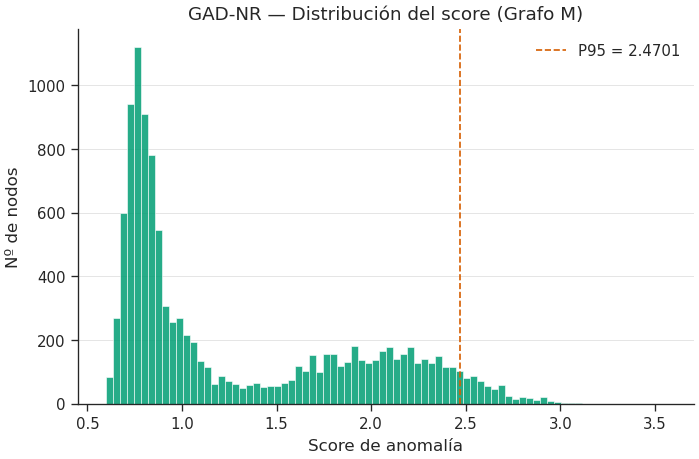

In [13]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_score_distribution_M.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distributions_M.png


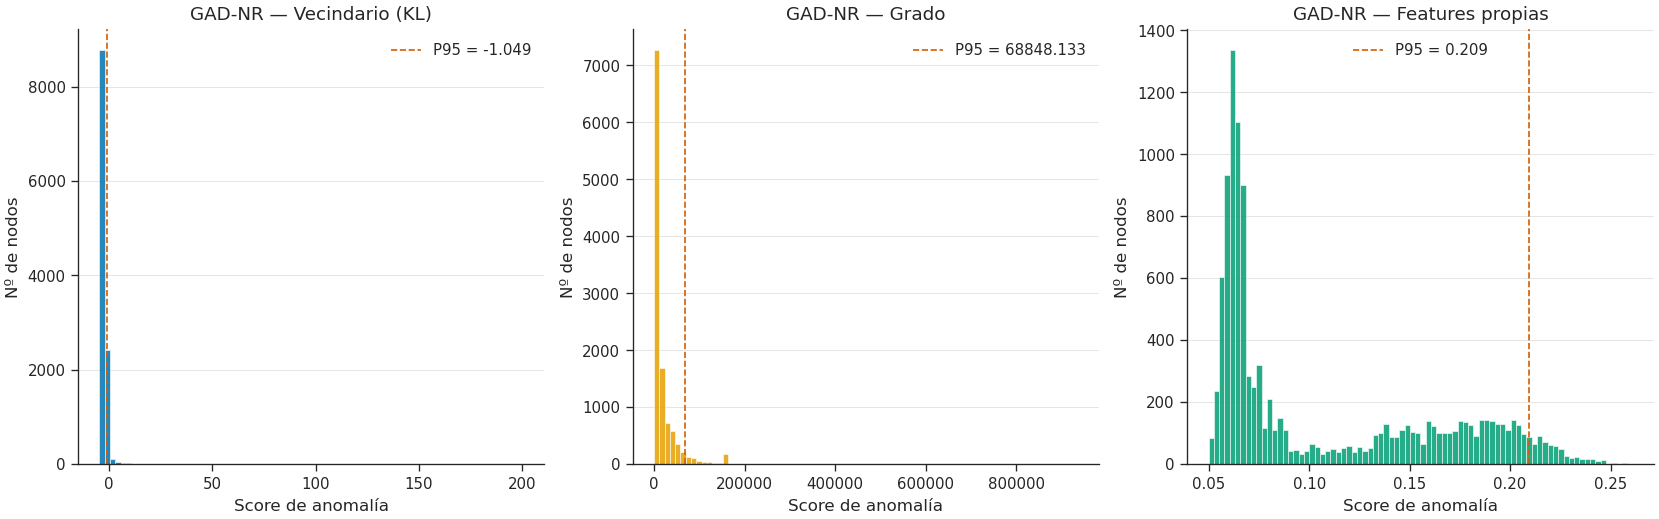

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = -0.1233
  Vecindario vs Features: ρ = 0.2620
  Grado      vs Features: ρ = 0.0336


In [14]:
# Distribución de los sub-scores de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

scores_info = [
    (gadnr_h,    'Vecindario (KL)',  CAT_COLORS[0]),
    (gadnr_deg,  'Grado',            CAT_COLORS[1]),
    (gadnr_feat, 'Features propias', CAT_COLORS[2]),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])

for ax, (scores, label, color) in zip(axes, scores_info):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '05_gadnr_score_distributions_M.png')
plt.show()

rho_h_deg,   _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,  _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat,_ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')

## 5. Comparativa por tipo de señal

Con los sub-scores extraídos de ambos modelos podemos hacer una comparativa
alineada con la taxonomía de anomalías de los papers originales
(Ding et al., 2019; Roy et al., 2024):

| Señal | Modelo | Tipo de anomalía |
|-------|--------|------------------|
|  | DOMINANT | Estructural — conectividad inusual |
|  | DOMINANT | Atributo — features distintas a la mayoría |
|  | GAD-NR | Estructural — grado inusual (señal análoga) |
|  | GAD-NR | Atributo — features distintas (señal análoga) |
|  | GAD-NR | **Joint-type** — features incompatibles con el vecindario |

La estructura de esta sección es:
1. Preparación del DataFrame con todos los sub-scores y percentiles
2. Comparativa estructural:  vs 
3. Comparativa de atributos:  vs 
4. Scatter de tipología por modelo (estilo referencia)
5. Análisis de la señal joint-type de GAD-NR (independiente)


In [15]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']     = gadnr_h
scores_df['gadnr_deg']   = gadnr_deg
scores_df['gadnr_feat']  = gadnr_feat
scores_df['gadnr_score'] = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (11371, 18)
Columnas: ['member_id', 'idx', 'name', 'city', 'state', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

Comparamos  (error de reconstrucción de adyacencia de DOMINANT)
con  (error de reconstrucción de grado de GAD-NR). Ambas señales
capturan anomalías estructurales pero desde perspectivas distintas: DOMINANT
mide si los enlaces del nodo se pueden reconstruir, mientras que GAD-NR mide
si su grado es predecible desde su embedding.

Una correlación alta indicaría que ambos modelos detectan las mismas anomalías
estructurales. Una baja indicaría información complementaria.


In [16]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

# Solapamiento top-100
K = 100
top_dom_struct   = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg    = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct   = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')

# Top-10 exclusivos de cada modelo en señal estructural
only_dom_struct   = top_dom_struct - top_gadnr_deg
only_gadnr_deg    = top_gadnr_deg  - top_dom_struct
print(f'Exclusivos DOMINANT-struct : {len(only_dom_struct)}')
print(f'Exclusivos GAD-NR-deg      : {len(only_gadnr_deg)}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.6472
Solapamiento top-100: 28/100 nodos comunes (28%)
Exclusivos DOMINANT-struct : 72
Exclusivos GAD-NR-deg      : 72


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_structural_comparison_M.png


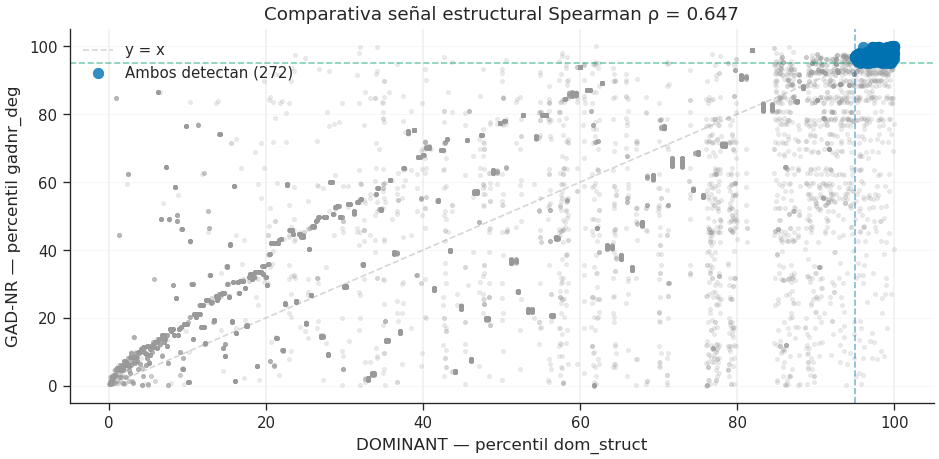

In [17]:
# Scatter comparativa estructural: dom_struct (X) vs gadnr_deg (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=6, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['M'],  linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color=PALETTE['neutral'],
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

# Nodos que ambos detectan como estructurales
ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=40, alpha=0.8, color=PALETTE['M'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural Spearman ρ = {rho_struct:.3f}',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_structural_comparison_M.png')
plt.show()


### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

Comparamos  (error de reconstrucción de features de DOMINANT)
con  (error de reconstrucción de features propias de GAD-NR).
Ambas señales miden si los atributos del nodo son inusuales, pero con
encoders distintos — DOMINANT usa un decoder GCN que reconstruye X desde Z,
mientras que GAD-NR usa un MLP que reconstruye las features iniciales desde
la representación final del nodo.


In [18]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

# Solapamiento top-100
top_dom_attr    = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat  = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr    = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')

only_dom_attr   = top_dom_attr  - top_gadnr_feat
only_gadnr_feat = top_gadnr_feat - top_dom_attr
print(f'Exclusivos DOMINANT-attr : {len(only_dom_attr)}')
print(f'Exclusivos GAD-NR-feat   : {len(only_gadnr_feat)}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = 0.8305
Solapamiento top-100: 0/100 nodos comunes (0%)
Exclusivos DOMINANT-attr : 100
Exclusivos GAD-NR-feat   : 100


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_attribute_comparison_M.png


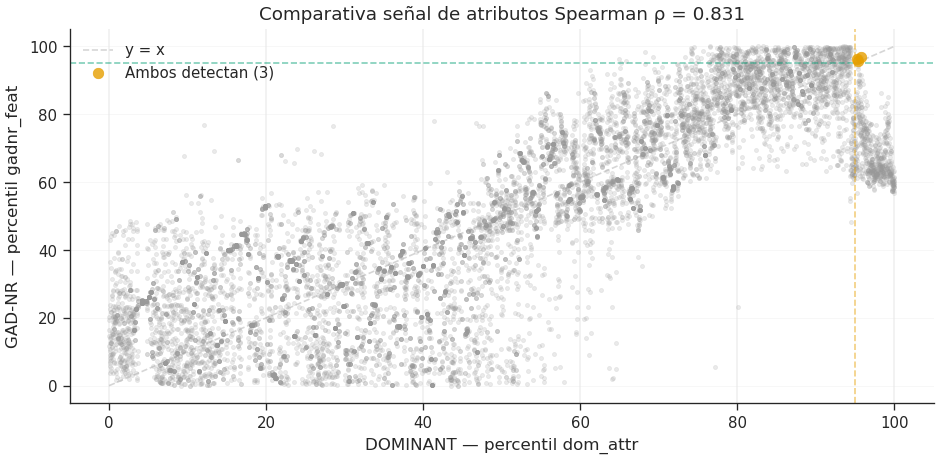

In [19]:
# Scatter comparativa de atributos: dom_attr (X) vs gadnr_feat (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=6, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['G'],  linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color=PALETTE['neutral'],
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

# Nodos que ambos detectan como atributo
ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=40, alpha=0.8, color=PALETTE['G'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos Spearman ρ = {rho_attr:.3f}',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_attribute_comparison_M.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Para cada modelo construimos el scatter estructural vs atributo con la
tipología de anomalías resultante, siguiendo el mismo estilo visual.

**DOMINANT:** usa sus dos señales propias ( vs ).
Solo puede detectar anomalías Estructurales, de Atributo y Mixtas.

**GAD-NR:** usa sus dos señales análogas ( vs ).
La comparación con DOMINANT revela si el modelo más avanzado redistribuye
los mismos nodos o detecta poblaciones distintas.


In [20]:
# Tipología DOMINANT: dom_struct vs dom_attr
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

# Tipología GAD-NR: gadnr_deg vs gadnr_feat
def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

print('=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         : 10247 (90.1%)
  Estructural    :   555 (4.9%)
  Atributo       :   553 (4.9%)
  Mixta          :    16 (0.1%)
=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         : 10267 (90.3%)
  Atributo       :   535 (4.7%)
  Estructural    :   535 (4.7%)
  Mixta          :    34 (0.3%)


c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_typology_dominant_M.png


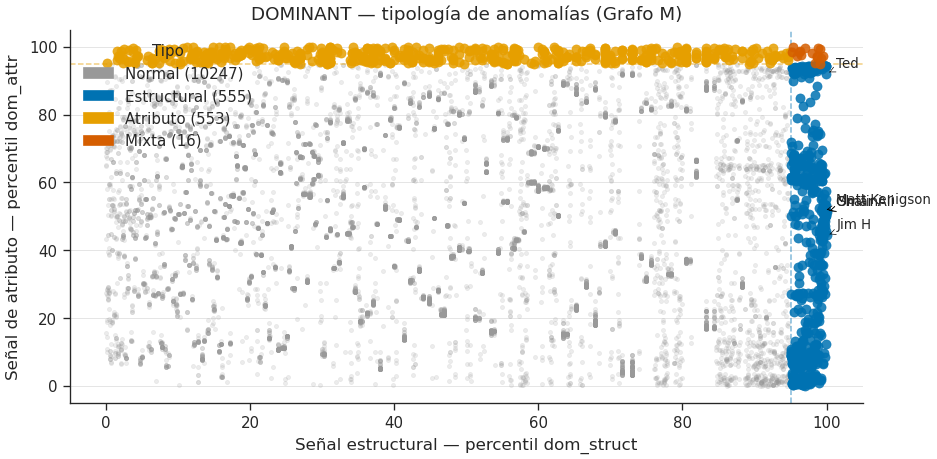

c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_typology_gadnr_M.png


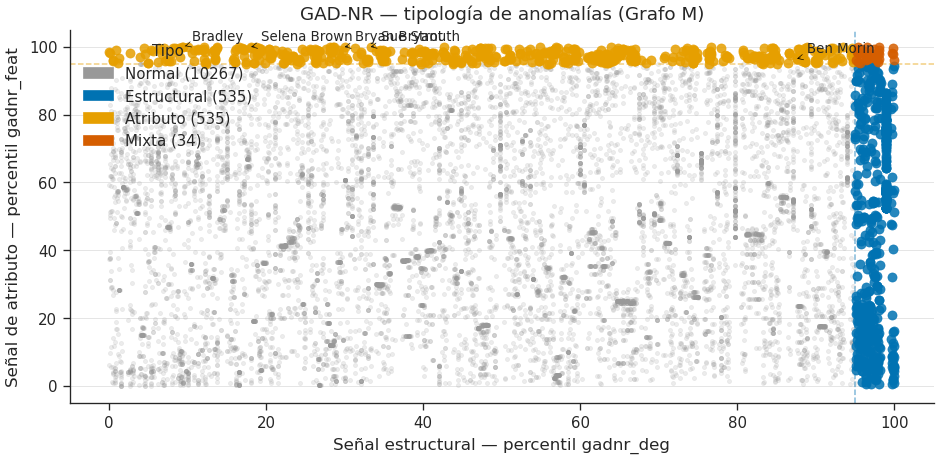

In [21]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {
    'Normal':      PALETTE['neutral'],
    'Estructural': PALETTE['M'],
    'Atributo':    PALETTE['G'],
    'Mixta':       PALETTE['anomaly'],
}

def plot_typology_scatter(ax, type_col, xcol, ycol, score_col, title,
                          xlabel, ylabel, top_n_labels=5):
    """Scatter de tipología para un modelo: x=estructural, y=atributo,
    coloreado por tipo asignado. Etiqueta los top-N por score compuesto."""
    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 30 if atype != 'Normal' else 6
        alpha  = 0.85 if atype != 'Normal' else 0.18
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=f'{atype} ({len(group)})', zorder=zorder)

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--',
               linewidth=0.9, alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--',
               linewidth=0.9, alpha=0.5)

    # Etiquetas de los nodos top-N por score combinado del modelo
    top = scores_df.nlargest(top_n_labels, score_col)
    for _, row in top.iterrows():
        ax.annotate(
            str(row['name'])[:18],
            (row[xcol], row[ycol]),
            fontsize=FONT['annotation'],
            xytext=(6, 4), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.4)
        )

    legend_patches = [mpatches.Patch(color=color_map[t],
                                     label=f"{t} ({(scores_df[type_col]==t).sum()})")
                      for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo',
              fontsize=FONT['legend'], frameon=False, loc='upper left')
    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['title'])
    polish(ax, grid=False)


# ── Figura 1: DOMINANT ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_dom',
    xcol='pct_dom_struct', ycol='pct_dom_attr',
    score_col='dom_combined',
    title='DOMINANT — tipología de anomalías (Grafo M)',
    xlabel='Señal estructural — percentil dom_struct',
    ylabel='Señal de atributo — percentil dom_attr',
)
plt.tight_layout()
save_figure(fig, '05_typology_dominant_M.png')
plt.show()


# ── Figura 2: GAD-NR ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_gadnr',
    xcol='pct_gadnr_deg', ycol='pct_gadnr_feat',
    score_col='gadnr_score',
    title='GAD-NR — tipología de anomalías (Grafo M)',
    xlabel='Señal estructural — percentil gadnr_deg',
    ylabel='Señal de atributo — percentil gadnr_feat',
)
plt.tight_layout()
save_figure(fig, '05_typology_gadnr_M.png')
plt.show()


### 5.4 Distribución del score compuesto por arquitectura

Cada arquitectura agrega sus sub-scores en un único score compuesto:

- **DOMINANT**: $s_i = (1-w) \cdot s^{struct}_i + w \cdot s^{attr}_i$ con $w=0.2$.
- **GAD-NR**: $s_i = \lambda_1 \cdot s^h_i + \lambda_2 \cdot s^{feat}_i + \lambda_3 \cdot s^{deg}_i$
  con los lambdas declarados (sin curriculum, gracias a `real_loss=False`).

Comparar las dos distribuciones del score compuesto permite ver cómo cada modelo
discrimina la cola de anomalías frente al cuerpo de la red. Una cola larga y bien
separada indica buen contraste; una distribución muy simétrica indica que el modelo
no está separando claramente las anomalías del resto.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_composite_score_distributions_M.png


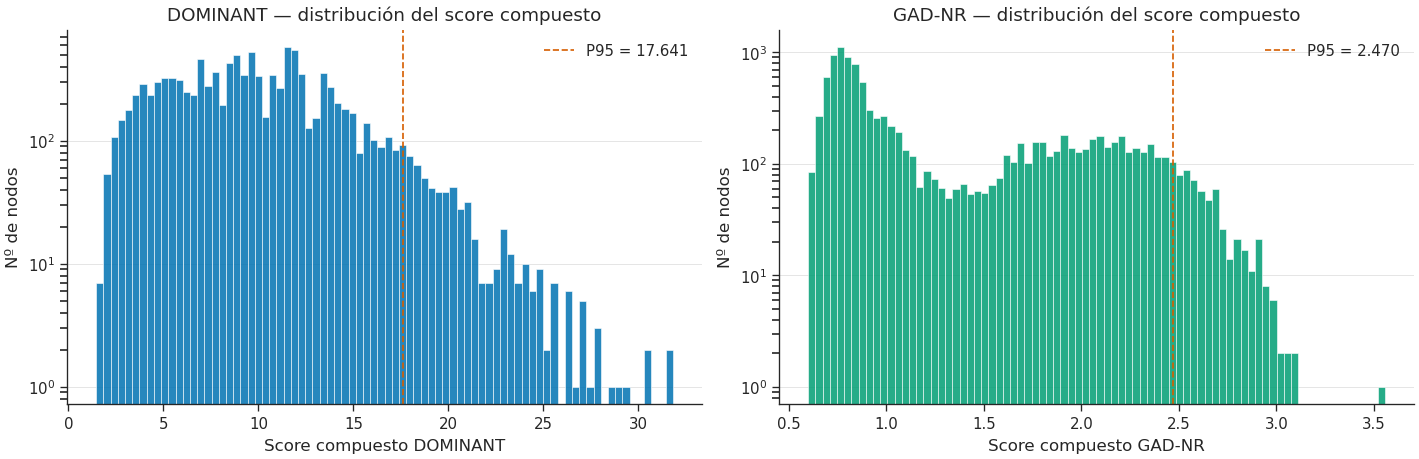

=== Score compuesto — DOMINANT ===
count    11371.000000
mean         9.831349
std          4.371622
min          1.461007
25%          6.527901
50%          9.506196
75%         12.289498
max         31.826422

=== Score compuesto — GAD-NR ===
count    11371.000000
mean         1.301106
std          0.639111
min          0.599095
25%          0.778074
50%          0.950584
75%          1.886515
max          3.555966

Correlación Spearman dom_combined vs gadnr_score: ρ = -0.0069
Solapamiento top-100: 0/100 (0%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

# DOMINANT
ax = axes[0]
ax.hist(scores_df['dom_combined'], bins=80,
        color=PALETTE['M'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(scores_df['dom_combined'], 95)
ax.axvline(p95_dom, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.3f}')
ax.set_xlabel('Score compuesto DOMINANT', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')   # cola larga; log resalta los outliers reales
polish(ax)

# GAD-NR
ax = axes[1]
ax.hist(scores_df['gadnr_score'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gad = np.percentile(scores_df['gadnr_score'], 95)
ax.axvline(p95_gad, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gad:.3f}')
ax.set_xlabel('Score compuesto GAD-NR', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
polish(ax)

plt.tight_layout()
save_figure(fig, '05_composite_score_distributions_M.png')
plt.show()

# Estadísticos descriptivos del score compuesto
print('=== Score compuesto — DOMINANT ===')
print(scores_df['dom_combined'].describe().to_string())
print('\n=== Score compuesto — GAD-NR ===')
print(scores_df['gadnr_score'].describe().to_string())

# Correlación Spearman entre los dos scores compuestos
rho_comp, _ = spearmanr(scores_df['dom_combined'], scores_df['gadnr_score'])
print(f'\nCorrelación Spearman dom_combined vs gadnr_score: ρ = {rho_comp:.4f}')

# Solapamiento del top-K
K = 100
top_dom = set(np.argsort(-scores_df['dom_combined'].values)[:K])
top_gad = set(np.argsort(-scores_df['gadnr_score'].values)[:K])
print(f'Solapamiento top-{K}: {len(top_dom & top_gad)}/{K} '
      f'({len(top_dom & top_gad)/K:.0%})')


### 5.5 Señal joint-type de GAD-NR (análisis independiente)

La señal **`gadnr_h`** — divergencia KL entre la distribución real de atributos
del vecindario y la reconstruida — es la única señal capaz de detectar
anomalías **joint-type**: nodos cuyas features son normales en sí mismas pero
no encajan con las features de sus vecinos.

Esta señal no tiene equivalente en DOMINANT. El análisis siguiente es
independiente y no compara con ninguna señal del otro modelo.


In [23]:
# Nodos con señal joint-type alta pero sin anomalía estructural ni de atributo
# según DOMINANT — los que DOMINANT no puede detectar
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Nodos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'city', 'state', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Nodos joint-type puros (invisibles para DOMINANT): 496
  Grado medio: 74.4 (vs 103.2 global)

Top-10 por gadnr_h:
         name           city state  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
    Tayla Roy    Spring Hill    TN       4        7.536716     83.554657   100.000000
          Wes       Franklin    TN      26       20.811714     80.810835    99.991206
      Sequina      Nashville    TN     249       92.582007     15.794565    99.982411
  Jeremy Flax       Franklin    TN      38       27.200774     61.067628    99.973617
Martin Shelby Hendersonville    TN     198       87.213086     91.953214    99.947234
          R P       Gallatin    TN      44       33.453522     78.392402    99.929646
         Quig Hendersonville    TN      98       58.921819     68.736259    99.912057
       Janice   Murfreesboro    TN      10       12.215284     90.286694    99.903263
      Loretta      Nashville    TN      38       26.936945     67.527042    99.885674
   Joey Bales      Hermita

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_joint_type_M.png


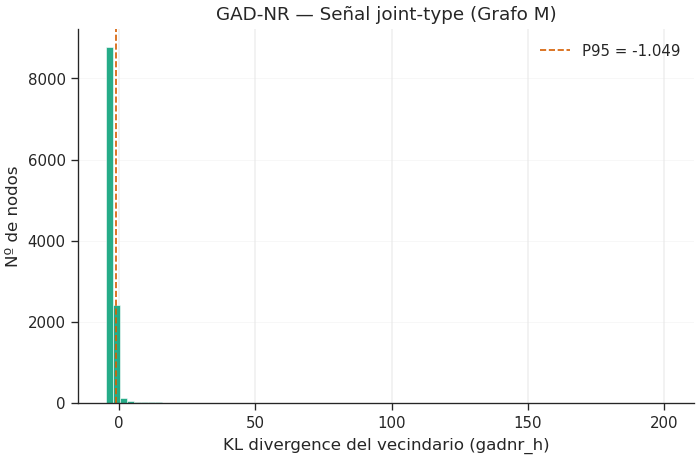

In [24]:
# Distribución del score joint-type
fig, ax = plt.subplots(figsize=FS['single'])

ax.hist(scores_df['gadnr_h'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')

ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_joint_type_M.png')
plt.show()


## 6. Spotlight — candidatos del EDA

Revisamos los candidatos identificados en el EDA con las cinco señales
disponibles. Para cada candidato mostramos el percentil en cada señal
y si supera el umbral P95.


In [25]:
def spotlight(name_fragment, df, label=None):
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):5d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):5d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):5d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):5d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):5d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '')

candidatos = [
    ('Pablo',         'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',       'Shalini (mayor betweenness de la red)'),
    ('Jim H',         'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson', 'Matt Kenigson (super-conector)'),
    ('GEEK',          'GEEK by AKEIN Engineering (entidad no personal)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)


CANDIDATOS DEL EDA — LAS 5 SEÑALES
  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688
    DOMINANT  estructural : #   12/11371  (99.9p) ⚠
    DOMINANT  atributo    : # 5112/11371  (55.1p)  
    GAD-NR    estructural : # 6808/11371  (40.1p)  
    GAD-NR    atributo    : #11062/11371  (2.7p)  
    GAD-NR    joint-type  : #    8/11371  (99.9p) ⚠

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955
    DOMINANT  estructural : #    1/11371  (100.0p) ⚠
    DOMINANT  atributo    : # 5534/11371  (51.3p)  
    GAD-NR    estructural : #   16/11371  (99.9p) ⚠
    GAD-NR    atributo    : #11161/11371  (1.9p)  
    GAD-NR    joint-type  : #    6/11371  (100.0p) ⚠

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178
    DOMINANT  estructural : #    2/11371  (100.0p) ⚠
    DOMINANT  atributo    : # 6329/11371  (44.3p)  
    GAD-NR    estructural : #    1/11371  (100.0p) ⚠
    GAD-NR    atributo  

In [26]:
# Tabla resumen ejecutivo
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)
    def rank(col): return int((scores_df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ''

    rows.append({
        'Candidato':      label.split('(')[0].strip(),
        'DOM-struct':     f'#{rank("dom_struct")} ({row["pct_dom_struct"]:.0f}p){flag(row["pct_dom_struct"])}',
        'DOM-attr':       f'#{rank("dom_attr")} ({row["pct_dom_attr"]:.0f}p){flag(row["pct_dom_attr"])}',
        'GADNR-struct':   f'#{rank("gadnr_deg")} ({row["pct_gadnr_deg"]:.0f}p){flag(row["pct_gadnr_deg"])}',
        'GADNR-attr':     f'#{rank("gadnr_feat")} ({row["pct_gadnr_feat"]:.0f}p){flag(row["pct_gadnr_feat"])}',
        'GADNR-joint':    f'#{rank("gadnr_h")} ({row["pct_gadnr_h"]:.0f}p){flag(row["pct_gadnr_h"])}',
    })

print('=== Resumen ejecutivo — candidatos del EDA ===')
print(pd.DataFrame(rows).to_string(index=False))


=== Resumen ejecutivo — candidatos del EDA ===
                Candidato  DOM-struct    DOM-attr GADNR-struct  GADNR-attr GADNR-joint
                    Pablo #12 (100p)⚠ #5112 (55p)  #6808 (40p) #11062 (3p)  #8 (100p)⚠
                  Shalini  #1 (100p)⚠ #5534 (51p)  #16 (100p)⚠ #11161 (2p)  #6 (100p)⚠
                    Jim H  #2 (100p)⚠ #6329 (44p)   #1 (100p)⚠ #10875 (4p)  #5 (100p)⚠
            Matt Kenigson  #3 (100p)⚠ #5465 (52p)  #415 (96p)⚠ #11326 (0p) #13 (100p)⚠
GEEK by AKEIN Engineering #11371 (0p) #3389 (70p)  #11315 (0p) #3385 (70p) #3966 (65p)


## 7. Comparativa general

Heatmap de correlación Spearman entre las cinco señales y análisis del
acuerdo entre modelos a nivel de etiqueta binaria (P95).


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_signal_correlation_M.png


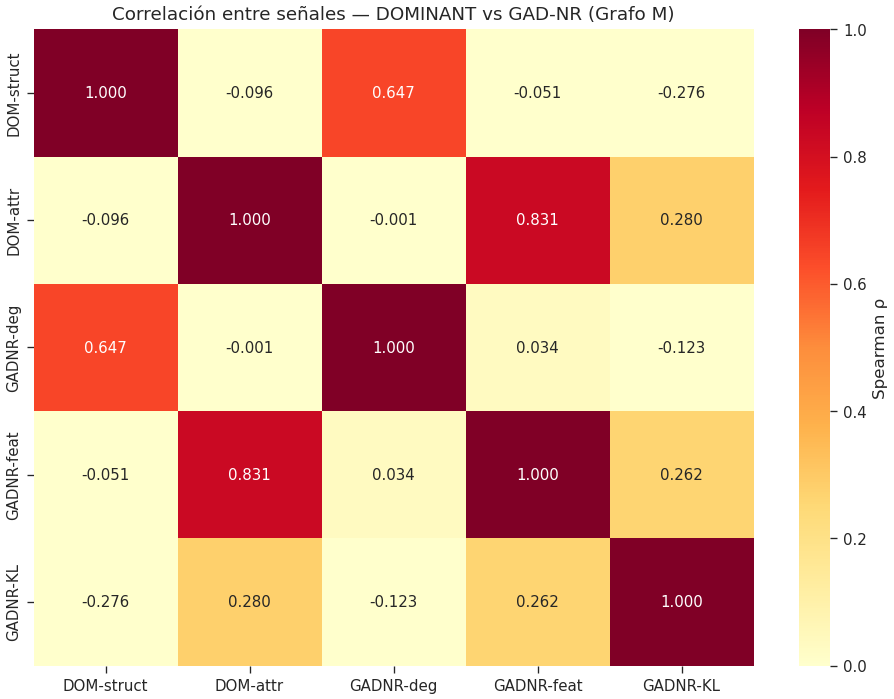

In [27]:
# Heatmap de correlación entre las 5 señales
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo M)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '05_signal_correlation_M.png')
plt.show()


In [28]:
# Acuerdo entre tipologías: ¿asignan el mismo tipo los dos modelos?
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Mixta  Normal
DOMINANT                                         
Atributo            3            9      0     541
Estructural        29          238     22     266
Mixta               0           12      0       4
Normal            503          276     12    9456


## 8. Visualización t-SNE de los embeddings

Para cerrar el análisis, proyectamos los **embeddings latentes** de cada modelo a 2D
mediante **t-SNE** (van der Maaten & Hinton, 2008). t-SNE preserva las relaciones
locales — nodos vecinos en el espacio latente quedan próximos en 2D — y es la
herramienta estándar para inspeccionar visualmente la estructura aprendida por una red.

Para cada modelo generamos tres vistas:

1. **Coloreado por tipo de anomalía** — verifica si los nodos asignados a una misma
   tipología se agrupan en el espacio latente del modelo. Una buena separación valida
   que el detector ha aprendido representaciones coherentes con su tipología.

2. **Coloreado por score compuesto** — gradiente continuo que muestra si la intensidad
   de anomalía sigue una estructura espacial (regiones del espacio latente con scores
   sistemáticamente altos).

3. **Coloreado por grado del nodo** — comprobación final: ¿el modelo está separando
   nodos por grado o ha aprendido representaciones más ricas? Una correlación
   perfecta entre grado y posición indicaría que el embedding es esencialmente una
   función del grado, lo cual es señal de poco aprendizaje.

**Coste computacional.** t-SNE con 11.371 puntos tarda 2-4 minutos por modelo en CPU.
Inicializamos con PCA (`init='pca'`) — más estable que `random` para muchos puntos —
y fijamos `random_state=SEED` para reproducibilidad.


In [29]:
# Extracción de embeddings finales de ambos modelos
@torch.no_grad()
def get_dominant_embeddings(detector, data):
    """
    El encoder GCN compartido de DOMINANT es la primera mitad del modelo.
    Llamamos a model.shared_encoder(x, edge_index) para obtener Z.
    """
    model = detector.model
    model.eval()
    x          = data.x.to(detector.device)
    edge_index = data.edge_index.to(detector.device)
    z = model.shared_encoder(x, edge_index)
    return z.cpu().numpy()


@torch.no_grad()
def get_gadnr_embeddings(detector, data):
    """
    GAD-NR: el encoder produce h0 (representación pre-decoder). Es el
    output de la GCN antes del MLP de reducción de vecindario.
    """
    model = detector.model
    model.eval()
    data.x          = data.x.to(detector.device)
    data.edge_index = data.edge_index.to(detector.device)
    h0, _, _, _ = model(data.x, data.edge_index)
    return h0.cpu().numpy()


emb_dom   = get_dominant_embeddings(dominant, data_M_clean)
emb_gadnr = get_gadnr_embeddings(gadnr,      data_M_clean)

print(f'Embeddings DOMINANT : {emb_dom.shape}')
print(f'Embeddings GAD-NR   : {emb_gadnr.shape}')


Embeddings DOMINANT : (11371, 64)
Embeddings GAD-NR   : (11371, 64)


In [30]:
from sklearn.manifold import TSNE

def run_tsne(embeddings, label):
    print(f'Calculando t-SNE sobre embeddings de {label}...')
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)


tsne_dom   = run_tsne(emb_dom,   'DOMINANT')
tsne_gadnr = run_tsne(emb_gadnr, 'GAD-NR')

print(f't-SNE DOMINANT shape: {tsne_dom.shape}')
print(f't-SNE GAD-NR  shape: {tsne_gadnr.shape}')


Calculando t-SNE sobre embeddings de DOMINANT...
Calculando t-SNE sobre embeddings de GAD-NR...
t-SNE DOMINANT shape: (11371, 2)
t-SNE GAD-NR  shape: (11371, 2)


c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_tsne_type_M.png


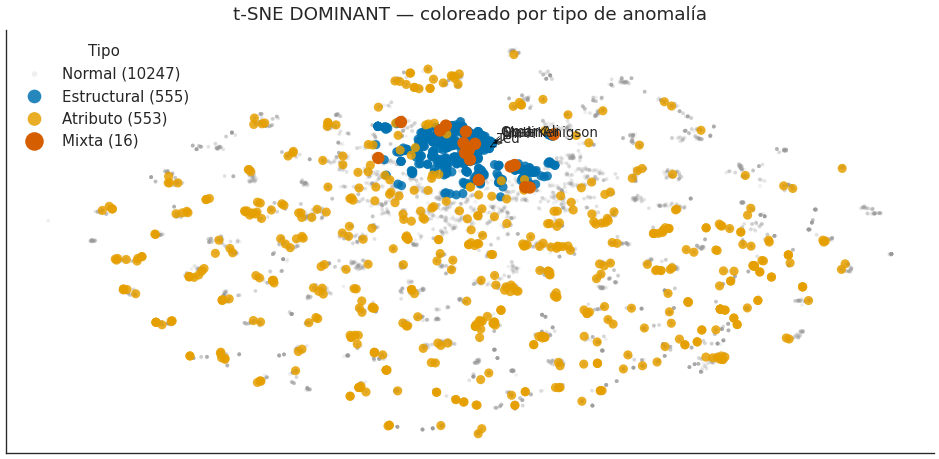

c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_tsne_score_M.png


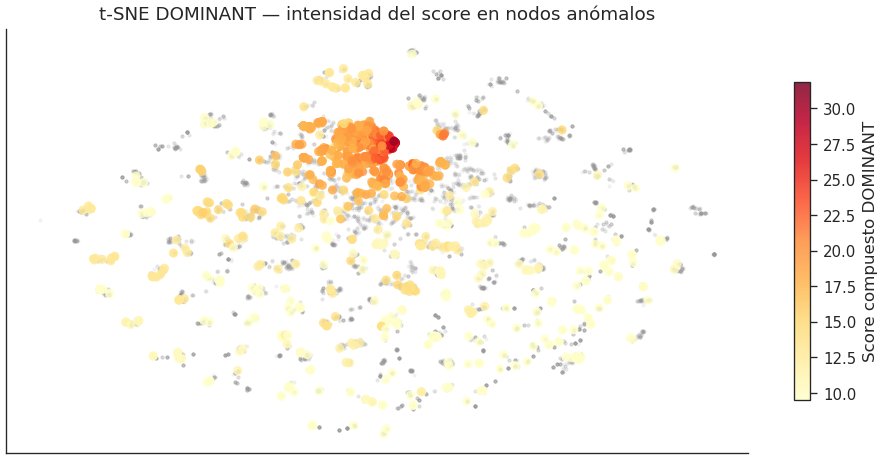

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_tsne_degree_M.png


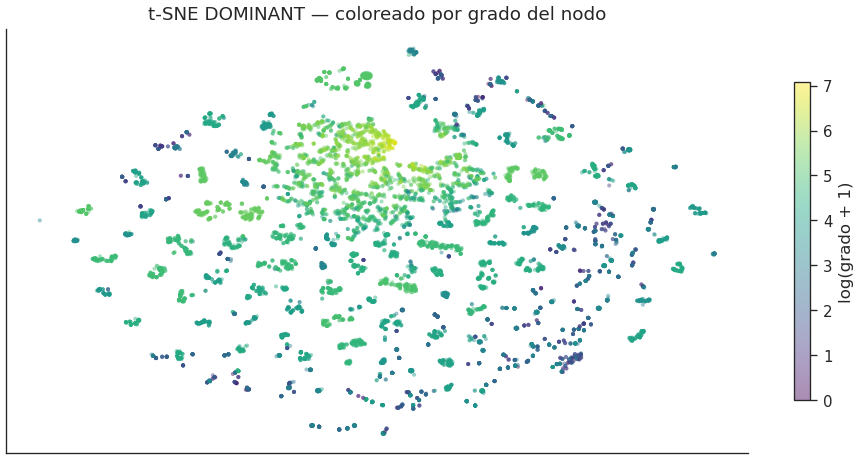

c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_tsne_type_M.png


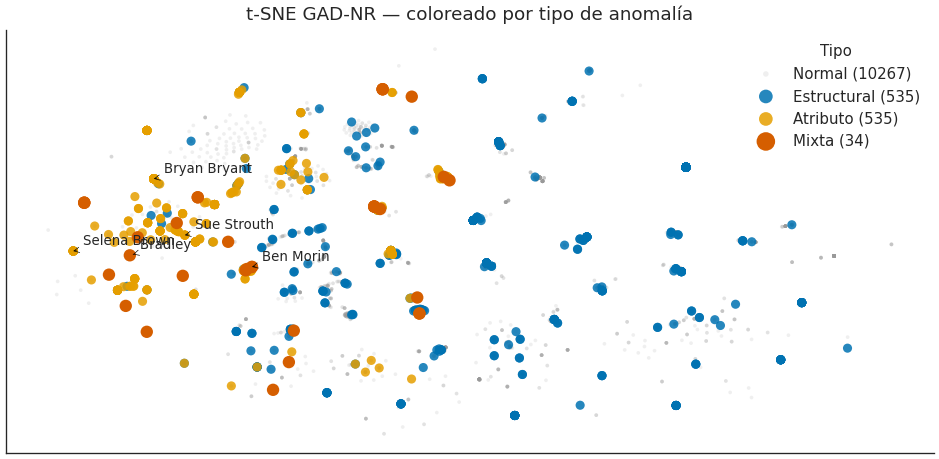

c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_tsne_score_M.png


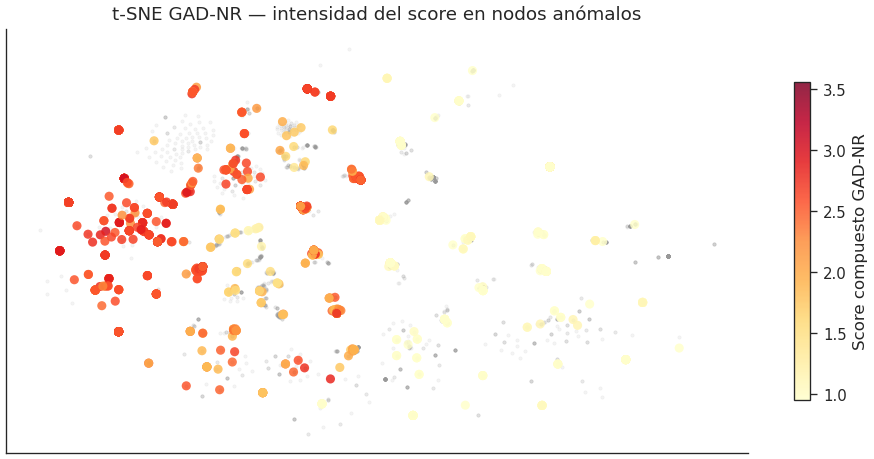

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_tsne_degree_M.png


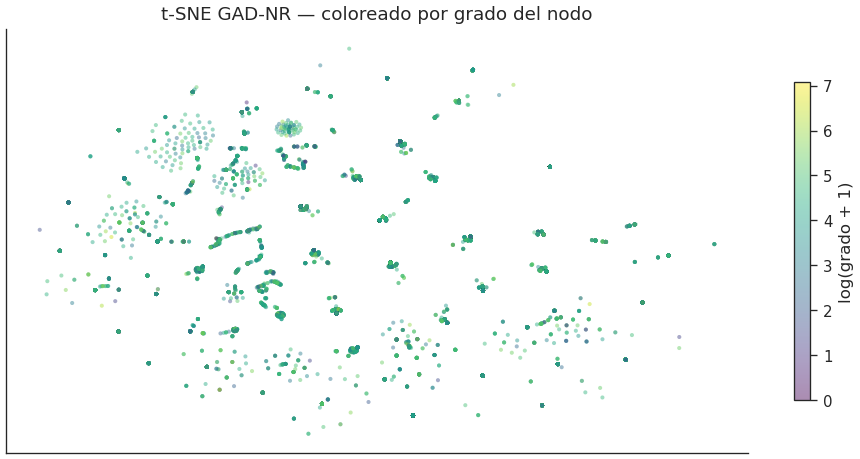

In [31]:
def plot_tsne_panel(tsne_coords, scores_df, model_name, type_col, score_col,
                    figname_prefix):
    """Genera las tres vistas t-SNE para un modelo: tipo, score, grado."""

    # ── Vista 1: tipo de anomalía ────────────────────────────────────────
    style_by_type = {
        'Normal':      (color_map['Normal'],      0.15,  5),
        'Estructural': (color_map['Estructural'], 0.85, 30),
        'Atributo':    (color_map['Atributo'],    0.85, 30),
        'Mixta':       (color_map['Mixta'],       1.00, 55),
    }

    fig, ax = plt.subplots(figsize=FS['wide'])
    # primero los normales (fondo)
    for atype in ['Normal', 'Estructural', 'Atributo', 'Mixta']:
        mask = scores_df[type_col] == atype
        color, alpha, size = style_by_type[atype]
        zorder = 1 if atype == 'Normal' else 3
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                   s=size, alpha=alpha, color=color,
                   label=f'{atype} ({mask.sum()})',
                   zorder=zorder, edgecolors='none')

    # Etiquetar el top-5 por score combinado
    top5 = scores_df.nlargest(5, score_col)
    for _, row in top5.iterrows():
        ax.annotate(str(row['name'])[:18],
                    (tsne_coords[row['idx'], 0], tsne_coords[row['idx'], 1]),
                    fontsize=FONT['annotation'],
                    xytext=(6, 4), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.4))

    ax.set_title(f't-SNE {model_name} — coloreado por tipo de anomalía',
                 fontsize=FONT['title'])
    ax.legend(title='Tipo', fontsize=FONT['legend'], frameon=False,
              markerscale=1.5, loc='best')
    ax.set_xticks([]); ax.set_yticks([])
    polish(ax, grid=False)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_type_M.png')
    plt.show()

    # ── Vista 2: score compuesto (gradiente continuo) ────────────────────
    fig, ax = plt.subplots(figsize=FS['wide'])
    normal_mask = scores_df[type_col] == 'Normal'
    ax.scatter(tsne_coords[normal_mask, 0], tsne_coords[normal_mask, 1],
               s=4, alpha=0.10, color=PALETTE['neutral'], zorder=1)

    anom_mask = ~normal_mask
    sc = ax.scatter(
        tsne_coords[anom_mask, 0], tsne_coords[anom_mask, 1],
        c=scores_df.loc[anom_mask, score_col],
        s=30, alpha=0.85, cmap=CMAP_HEAT, zorder=3,
        vmin=scores_df[score_col].quantile(0.5),
        vmax=scores_df[score_col].max(),
        edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label(f'Score compuesto {model_name}', fontsize=FONT['axis_label'])
    ax.set_title(f't-SNE {model_name} — intensidad del score en nodos anómalos',
                 fontsize=FONT['title'])
    ax.set_xticks([]); ax.set_yticks([])
    polish(ax, grid=False)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_score_M.png')
    plt.show()

    # ── Vista 3: grado del nodo (escala log) ─────────────────────────────
    fig, ax = plt.subplots(figsize=FS['wide'])
    sc = ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c=np.log1p(scores_df['degree']),
        s=6, alpha=0.45, cmap=CMAP_SEQ, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label('log(grado + 1)', fontsize=FONT['axis_label'])
    ax.set_title(f't-SNE {model_name} — coloreado por grado del nodo',
                 fontsize=FONT['title'])
    ax.set_xticks([]); ax.set_yticks([])
    polish(ax, grid=False)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_degree_M.png')
    plt.show()


# t-SNE DOMINANT
plot_tsne_panel(
    tsne_coords=tsne_dom,
    scores_df=scores_df,
    model_name='DOMINANT',
    type_col='type_dom',
    score_col='dom_combined',
    figname_prefix='05_dominant',
)

# t-SNE GAD-NR
plot_tsne_panel(
    tsne_coords=tsne_gadnr,
    scores_df=scores_df,
    model_name='GAD-NR',
    type_col='type_gadnr',
    score_col='gadnr_score',
    figname_prefix='05_gadnr',
)


## 9. Guardado de resultados


In [32]:
cols_export = [
    'idx', 'member_id', 'name', 'city', 'state', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_M.csv')
print(f'Shape    : {scores_export.shape}')

# Embeddings finales y coordenadas t-SNE
np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_M.npz'),
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
    member_ids=np.array(member_ids),
)
print(f'Guardado : {RESULTS_PATH}embeddings_M.npz')


Guardado : ../data/results/scores_M.csv
Shape    : (11371, 20)
Guardado : ../data/results/embeddings_M.npz


## Resumen del notebook

En este notebook hemos:

1. **Entrenado DOMINANT** y extraído `dom_struct` (estructural) y `dom_attr` (atributo).

2. **Entrenado GAD-NR** con `real_loss=False` para evitar el curriculum explosivo
   y declarar lambdas explícitos ajustados a la escala de cada loss en el grafo M.
   Extraído `gadnr_h` (vecindario / joint-type), `gadnr_deg` (estructural) y
   `gadnr_feat` (atributo).

3. **Comparado las señales equivalentes** estructural vs estructural y atributo
   vs atributo mediante correlación Spearman, solapamiento top-K y scatters de
   tipología separados por modelo.

4. **Comparado los scores compuestos** de ambas arquitecturas mediante histogramas
   (eje y log) y correlación Spearman.

5. **Analizado la señal joint-type** de GAD-NR de forma independiente,
   identificando los nodos invisibles para DOMINANT que sólo GAD-NR detecta.

6. **Validado los candidatos del EDA** con las cinco señales.

7. **Visualizado los embeddings latentes** de ambos modelos con t-SNE en tres
   vistas (tipo de anomalía, score compuesto y grado del nodo), permitiendo
   inspeccionar visualmente la estructura aprendida por cada detector.

Los resultados quedan en `scores_M.csv` y `embeddings_M.npz`.
